# Wayfair E-commerce Sales Analysis

By: Vinay Jagtap

The e-commerce team needed a clean read on how 2024 and 2025 performed before locking in next year's plan. The order export was raw, so I spent most of the time cleaning it before any analysis. This notebook walks through the whole thing start to finish.

# Loading and setting up paths and all the required libraries.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.size"] = 10

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

Base   = "C:/Users/vinay/OneDrive/Desktop/Data Science and Analytics Projects/Wayfair Sales Analysis"
Raw    = f"{Base}/Data/Raw Data"
Clean  = f"{Base}/Data/Cleaned Data"
Charts = f"{Base}/Charts"

os.makedirs(Clean, exist_ok=True)
os.makedirs(Charts, exist_ok=True)

print("pandas", pd.__version__)
print("All the libraries and paths loaded successfully!!")

pandas 2.3.3
All the libraries and paths loaded successfully!!


## Loading the csv files

Reading all four exports. Parsed order_date and signup_date on load so I do not have to deal with string slicing later.

In [2]:
orders    = pd.read_csv(f"{Raw}/orders.csv", parse_dates=["order_date"])
items     = pd.read_csv(f"{Raw}/order_items.csv")
products  = pd.read_csv(f"{Raw}/products.csv")
customers = pd.read_csv(f"{Raw}/customers.csv", parse_dates=["signup_date"])

print(f"orders      {orders.shape[0]:>6,} rows  x {orders.shape[1]} cols")
print(f"order_items {items.shape[0]:>6,} rows  x {items.shape[1]} cols")
print(f"products    {products.shape[0]:>6,} rows  x {products.shape[1]} cols")
print(f"customers   {customers.shape[0]:>6,} rows  x {customers.shape[1]} cols")

orders       9,245 rows  x 7 cols
order_items 15,608 rows  x 5 cols
products        90 rows  x 5 cols
customers    3,600 rows  x 4 cols


## Inspecting csv files

Before touching anything I want the shape, the dtypes, the missing counts, and the duplicate counts for each file. Same function for all four so I do not miss anything.

## Inspection helper function


In [7]:
def inspect(df, name):
    print("-" * 70)
    print(name.upper())
    print("-" * 70)
    print(f"Shape            : {df.shape}")
    print(f"Exact duplicates : {df.duplicated().sum()}")
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing):
        print("Missing values   :")
        for col, cnt in missing.items():
            print(f"    {col:<20} {cnt:>6,}")
    else:
        print("Missing values   : none")
    print(f"Memory           : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
    print()

## Inspecting orders.csv

In [6]:
inspect(orders, "orders")

print("First 5 rows:")
display(orders.head())

print("Last 5 rows:")
display(orders.tail())

print("Dtypes:")
display(orders.dtypes.to_frame("dtype"))

------------------------------------------------------------------------
ORDERS
------------------------------------------------------------------------
Shape            : (9245, 7)
Exact duplicates : 38
Missing values   :
    discount_code         7,834
Memory           : 1664.8 KB

First 5 rows:


,order_id,customer_id,order_date,status,payment_method,discount_code,shipping_fee
0,100001,1530,2024-01-01 09:24:45,completed,credit_card,NaN,6.95
1,100002,3531,2024-01-01 10:37:49,completed,credit_card,NaN,0.00
2,100003,840,2024-01-01 10:59:09,completed,credit_card,NaN,0.00
3,100004,725,2024-01-01 12:48:34,completed,apple_pay,WELCOME10,0.00
4,100005,3452,2024-01-01 17:44:03,completed,gift_card,NaN,0.00


Last 5 rows:


,order_id,customer_id,order_date,status,payment_method,discount_code,shipping_fee
9240,109203,3499,2025-12-31 16:50:18,completed,credit_card,HOLIDAY20,6.95
9241,109204,3410,2025-12-31 17:40:58,completed,credit_card,HOLIDAY20,0.00
9242,109205,2911,2025-12-31 18:21:51,completed,credit_card,NaN,0.00
9243,109206,1157,2025-12-31 21:38:59,completed,credit_card,NaN,6.95
9244,109207,2208,2025-12-31 23:23:29,completed,paypal,HOLIDAY20,0.00


Dtypes:


,dtype
order_id,int64
customer_id,int64
order_date,datetime64[ns]
status,object
payment_method,object
discount_code,object
shipping_fee,float64


# Orders in detail

In [8]:
print("Status values:", orders["status"].unique())
print("Payment methods:", orders["payment_method"].unique())
print("Discount codes:", orders["discount_code"].dropna().unique())

print()
print("Status distribution:")
display(orders["status"].value_counts().to_frame("count"))

print("Payment method distribution:")
display(orders["payment_method"].value_counts().to_frame("count"))

print("Discount code distribution (nulls kept):")
display(orders["discount_code"].value_counts(dropna=False).to_frame("count"))

print(f"Date range: {orders['order_date'].min()} to {orders['order_date'].max()}")

dupes = orders[orders.duplicated(subset=["order_id"], keep=False)]
print(f"\nRows with a repeated order_id: {len(dupes)}")
print(f"Unique order_ids involved    : {dupes['order_id'].nunique()}")

print("\nSample of repeated order_id rows:")
display(dupes.sort_values("order_id").head(10))

print("Shipping fee summary:")
display(orders["shipping_fee"].describe().to_frame("shipping_fee"))

Status values: ['completed' 'returned' 'canceled']
Payment methods: ['credit_card' 'apple_pay' 'gift_card' 'paypal']
Discount codes: ['WELCOME10' 'SPRING15' 'HOLIDAY20']

Status distribution:


,count
status,
completed,8490
returned,409
canceled,346


Payment method distribution:


,count
payment_method,
credit_card,5332
paypal,1959
apple_pay,1422
gift_card,532


Discount code distribution (nulls kept):


,count
discount_code,
NaN,7834
HOLIDAY20,782
WELCOME10,391
SPRING15,238


Date range: 2024-01-01 09:24:45 to 2025-12-31 23:23:29

Rows with a repeated order_id: 76
Unique order_ids involved    : 38

Sample of repeated order_id rows:


,order_id,customer_id,order_date,status,payment_method,discount_code,shipping_fee
47,100048,3320,2024-01-06 16:37:36,completed,credit_card,NaN,6.95
8560,100048,3320,2024-01-06 16:37:36,completed,credit_card,NaN,6.95
7556,100303,853,2024-02-03 08:33:22,completed,apple_pay,NaN,0.00
303,100303,853,2024-02-03 08:33:22,completed,apple_pay,NaN,0.00
5488,100710,526,2024-03-13 13:39:17,completed,credit_card,NaN,0.00
712,100710,526,2024-03-13 13:39:17,completed,credit_card,NaN,0.00
781,100779,1209,2024-03-20 11:07:55,completed,gift_card,NaN,0.00
6700,100779,1209,2024-03-20 11:07:55,completed,gift_card,NaN,0.00
2747,101380,2821,2024-05-15 16:28:12,completed,credit_card,NaN,0.00
1383,101380,2821,2024-05-15 16:28:12,completed,credit_card,NaN,0.00


Shipping fee summary:


,shipping_fee
count,"9,245.00"
mean,1.54
std,2.89
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,6.95


## Inspecting order_items.csv

In [9]:
inspect(items, "order_items")

print("First 5 rows:")
display(items.head())

print("Last 5 rows:")
display(items.tail())

print("Dtypes:")
display(items.dtypes.to_frame("dtype"))

----------------------------------------------------------------------
ORDER_ITEMS
----------------------------------------------------------------------
Shape            : (15608, 5)
Exact duplicates : 0
Missing values   :
    unit_price              199
Memory           : 609.8 KB

First 5 rows:


,order_id,product_id,quantity,unit_price,discount_amount
0,100001,1031,1,38.99,0.00
1,100002,1087,1,45.99,0.00
2,100002,1072,1,141.99,0.00
3,100003,1048,1,139.99,0.00
4,100004,1083,1,19.99,2.00


Last 5 rows:


,order_id,product_id,quantity,unit_price,discount_amount
15603,109204,1070,1,129.14,25.83
15604,109205,1072,2,149.09,0.00
15605,109206,1071,1,10.49,0.00
15606,109207,1023,2,142.79,57.12
15607,109207,1043,1,134.39,26.88


Dtypes:


,dtype
order_id,int64
product_id,int64
quantity,int64
unit_price,float64
discount_amount,float64


## Items in detail

In [11]:
missing_price = items["unit_price"].isnull().sum()
print(f"Missing uni_price: {missing_price} ({missing_price / len(items) * 100:.2f}%)")

by_product = (
    items[items["unit_price"].isnull()]
    .groupby("product_id")
    .size()
    .sort_values(ascending = False)
    .to_frame("missing_lines")

)
print("\nMissing price by product_id, top 10:")
display(by_product.head(10))

print("Quantity summary:")
display(items["quantity"].describe().to_frame("quantity"))

print("Discount amount summary:")
display(items["discount_amount"].describe().to_frame("discount_amount"))

print(f"Quantity 0 or negative   : {(items['quantity'] <= 0).sum()}")
print(f"Negative discount amount   : {(items['discount_amount'] < 0).sum()}")
print(f"Exact duplicate rows     : {items.duplicated().sum()}")
print(f"Duplicate order+product  : {items.duplicated(subset=['order_id', 'product_id']).sum()}")

Missing uni_price: 199 (1.27%)

Missing price by product_id, top 10:


,missing_lines
product_id,
1070,8
1006,5
1074,5
1060,5
1087,5
1015,5
1068,4
1053,4
1029,4


Quantity summary:


,quantity
count,"15,608.00"
mean,1.24
std,0.58
min,1.00
25%,1.00
50%,1.00
75%,1.00
max,4.00


Discount amount summary:


,discount_amount
count,"15,608.00"
mean,3.20
std,11.15
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,196.56


Quantity 0 or negative   : 0
Negative discount amount   : 0
Exact duplicate rows     : 0
Duplicate order+product  : 0


## Inspecting products.csv

In [12]:
inspect(products, "products")

print("First 5 rows:")
display(products.head())

print("Last 5 rows:")
display(products.tail())

print("Dtypes:")
print(products.dtypes.to_frame("dtype"))

----------------------------------------------------------------------
PRODUCTS
----------------------------------------------------------------------
Shape            : (90, 5)
Exact duplicates : 0
Missing values   : none
Memory           : 13.1 KB

First 5 rows:


,product_id,product_name,category,list_price,unit_cost
0,1001,Brass Chef Knife,Kitchen,61.99,38.13
1,1002,Walnut Cutting Board,Kitchen,138.99,74.76
2,1003,Matte Black Dutch Oven,Kitchen,22.99,13.50
3,1004,Classic Skillet,Kitchen,75.99,39.86
4,1005,Linen Mixing Bowl Set,Kitchen,79.99,41.11


Last 5 rows:


,product_id,product_name,category,list_price,unit_cost
85,1086,Modern Under Bed Bin,Storage,97.99,43.62
86,1087,Cotton Pantry Container Set,Storage,45.99,20.30
87,1088,Coastal Coat Rack,Storage,20.99,12.03
88,1089,Modern Floating Shelf,Storage,53.99,24.22
89,1090,Bamboo Laundry Basket,Storage,17.99,7.79


Dtypes:
                dtype
product_id      int64
product_name   object
category       object
list_price    float64
unit_cost     float64


## Products in detail

In [13]:
print("Raw category counts:")
display(products["category"].value_counts().to_frame("count"))

print(f"\nUnique raw labels: {products['category'].nunique()}")

print("\nEvery raw label, wrapped in quotes so spaces are visible:")
for label in sorted(products["category"].unique()):
    print(f"    {repr(label)}")

print(f"\nMissing list_price: {products['list_price'].isnull().sum()}")
print(f"Missing unit_cost : {products['unit_cost'].isnull().sum()}")

print("\nList price summary:")
display(products["list_price"].describe().to_frame("list_price"))

print("Unit cost summary:")
display(products["unit_cost"].describe().to_frame("unit_cost"))

Raw category counts:


,count
category,
Kitchen,10
Outdoor,9
Furniture,9
Bath,9
Lighting,8
Bedding,8
Decor,8
Storage,7
decor,4



Unique raw labels: 24

Every raw label, wrapped in quotes so spaces are visible:
    ' Bedding'
    ' Kitchen'
    ' Outdoor'
    'BEDDING'
    'Bath'
    'Bedding'
    'Decor'
    'FURNITURE'
    'Furniture'
    'Furniture '
    'KITCHEN'
    'Kitchen'
    'Kitchen '
    'LIGHTING'
    'Lighting'
    'OUTDOOR'
    'Outdoor'
    'Storage'
    'Storage '
    'bath'
    'bedding'
    'decor'
    'furniture'
    'kitchen'

Missing list_price: 0
Missing unit_cost : 0

List price summary:


,list_price
count,90.00
mean,134.38
std,136.90
min,7.99
25%,52.49
50%,95.49
75%,151.49
max,773.99


Unit cost summary:


,unit_cost
count,90.00
mean,69.56
std,76.82
min,4.76
25%,24.55
50%,49.28
75%,74.33
max,445.47


## Inspecting customers.csv

In [14]:
inspect(customers, "customers")

print("First 5 rows:")
display(customers.head())

print("Last 5 rows:")
display(customers.tail())

print("Dtypes:")
display(customers.dtypes.to_frame("dtype"))

----------------------------------------------------------------------
CUSTOMERS
----------------------------------------------------------------------
Shape            : (3600, 4)
Exact duplicates : 0
Missing values   : none
Memory           : 446.3 KB

First 5 rows:


,customer_id,signup_date,state,acquisition_channel
0,1,2024-09-13,CO,organic_search
1,2,2025-10-21,IL,paid_search
2,3,2025-01-17,AZ,referral
3,4,2024-06-23,FL,paid_social
4,5,2025-04-08,IL,paid_social


Last 5 rows:


,customer_id,signup_date,state,acquisition_channel
3595,3596,2025-11-14,LA,referral
3596,3597,2025-05-27,WA,paid_search
3597,3598,2024-06-03,CA,paid_search
3598,3599,2025-08-23,LA,organic_search
3599,3600,2024-10-19,NY,organic_search


Dtypes:


,dtype
customer_id,int64
signup_date,datetime64[ns]
state,object
acquisition_channel,object


## Customers in detail

In [15]:
print(f"Unique states: {customers['state'].nunique()}")
print("State list:")
print(sorted(customers["state"].unique()))

print("\nAcquisition channel counts:")
display(customers["acquisition_channel"].value_counts().to_frame("count"))

print(f"\nSignup range: {customers['signup_date'].min()} to {customers['signup_date'].max()}")

print("\nAny missing values:")
display(customers.isnull().sum().to_frame("missing"))

Unique states: 35
State list:
['AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'FL', 'GA', 'IA', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'MI', 'MN', 'MO', 'NC', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'SC', 'TN', 'TX', 'UT', 'VA', 'WA', 'WI']

Acquisition channel counts:


,count
acquisition_channel,
organic_search,1230
paid_social,831
paid_search,550
email,423
referral,367
affiliate,199



Signup range: 2023-06-05 00:00:00 to 2025-12-19 00:00:00

Any missing values:


,missing
customer_id,0
signup_date,0
state,0
acquisition_channel,0


## Inspection notes

What I found:

orders.csv:

9,245 rows, 7 columns. 38 order_ids appear twice, so 76 rows involved. All duplicated rows are exact copies, so the second one can be dropped. Date range covers exactly what was expected, Jan 2024 to Dec 2025. Status has three values, all lowercase. Payment methods look clean. Discount codes look clean. 7,834 orders have no promo code, which is normal.

order_items.csv:

15,608 rows, 5 columns. 199 rows missing unit_price (1.27%). Spread across many products, no obvious pattern. No negative quantities, no negative discounts, no duplicate rows. Quantity range is fine.

products.csv:

90 rows, 5 columns. No missing values. Category column is a mess. 24 raw labels for what should be 8 real categories. Extra spaces, mixed case, all the usual export issues. This is the biggest cleanup item.

customers.csv:

3,600 rows, 4 columns. Completely clean. No missing values, no duplicates, consistent formatting.

## Cleaning

Rules I am following.

Raw files stay untouched. Cleaned versions go to Data/Cleaned Data.

Every decision gets written down here so anyone reading can trace it.

Decision log:

orders.csv:

1. Drop 38 duplicate order_id rows, keeping the first occurrence. Duplicates would double count revenue.
2. Lowercase and strip status, payment_method, discount_code. None of them needed a change but this future proofs the join keys.
3. Leave null discount_code values alone. Null means no promo was used. Filling with "NONE" would create a fake category.
4. Add month, year, month_num columns from order_date. Makes the monthly grouping one line.

order_items.csv:

5. Fill 199 missing unit_price values from products.list_price matched on product_id. The catalog price is the best proxy available.
6. If a product still has no price, fall back to the median unit_price for that product across all its orders. Median over mean because it is not skewed by outliers.
7. If a line still has no price after both, drop it and note it. I expect zero rows to reach this step.
8. Add line_revenue column: quantity * unit_price - discount_amount. Used in revenue definition later.

products.csv:

9. Strip whitespace and apply title case to category. 24 labels collapse to 8.
10. Add margin and margin_pct columns for profit analysis.

customers.csv:

11. Uppercase state, lowercase acquisition_channel. No changes expected but keeps things consistent.
12. Add signup_year and signup_month columns for cohort analysis.

## Cleaning orders.csv

In [16]:
before = len(orders)
orders = orders.drop_duplicates(subset=["order_id"], keep="first").reset_index(drop=True)
print(f"Dropped {before - len(orders)} duplicate rows")

for col in ["status", "payment_method", "discount_code"]:
    orders[col] = orders[col].astype(str).str.strip().str.lower()
orders["discount_code"] = orders["discount_code"].replace("nan", np.nan)

orders["month"]     = orders["order_date"].dt.to_period("M")
orders["year"]      = orders["order_date"].dt.year
orders["month_num"] = orders["order_date"].dt.month

print(f"Rows after cleaning: {len(orders):,}")

print("\nStatus counts after clean:")
display(orders["status"].value_counts().to_frame("count"))

print("Cleaned orders preview:")
display(orders.head())

Dropped 38 duplicate rows
Rows after cleaning: 9,207

Status counts after clean:


,count
status,
completed,8456
returned,407
canceled,344


Cleaned orders preview:


,order_id,customer_id,order_date,status,payment_method,discount_code,shipping_fee,month,year,month_num
0,100001,1530,2024-01-01 09:24:45,completed,credit_card,NaN,6.95,2024-01,2024,1
1,100002,3531,2024-01-01 10:37:49,completed,credit_card,NaN,0.00,2024-01,2024,1
2,100003,840,2024-01-01 10:59:09,completed,credit_card,NaN,0.00,2024-01,2024,1
3,100004,725,2024-01-01 12:48:34,completed,apple_pay,welcome10,0.00,2024-01,2024,1
4,100005,3452,2024-01-01 17:44:03,completed,gift_card,NaN,0.00,2024-01,2024,1


## Cleaning order_items.csv

In [17]:
items = items.merge(products[["product_id", "list_price"]], on="product_id", how="left")

filled_from_catalog = items["unit_price"].isnull() & items["list_price"].notnull()
items.loc[filled_from_catalog, "unit_price"] = items.loc[filled_from_catalog, "list_price"]

print(f"Filled from catalog : {filled_from_catalog.sum()}")

still_missing = items["unit_price"].isnull().sum()
print(f"Still missing       : {still_missing}")

if still_missing:
    items["unit_price"] = items["unit_price"].fillna(
        items.groupby("product_id")["unit_price"].transform("median")
    )
    print(f"After median fill   : {items['unit_price'].isnull().sum()}")

final_missing = items["unit_price"].isnull().sum()
if final_missing:
    print(f"Dropping {final_missing} rows with no price recoverable")
    items = items.dropna(subset=["unit_price"]).reset_index(drop=True)

items = items.drop(columns=["list_price"])

items["line_revenue"] = items["quantity"] * items["unit_price"] - items["discount_amount"]

assert (items["unit_price"] > 0).all(), "Non positive price found"
assert (items["line_revenue"] >= 0).all(), "Negative revenue found"

print(f"\nFinal shape: {items.shape}")
print(f"Line revenue range: ${items['line_revenue'].min():.2f} to ${items['line_revenue'].max():.2f}")

print("\nCleaned order_items preview:")
display(items.head())

Filled from catalog : 199
Still missing       : 0

Final shape: (15608, 6)
Line revenue range: $6.39 to $1871.96

Cleaned order_items preview:


,order_id,product_id,quantity,unit_price,discount_amount,line_revenue
0,100001,1031,1,38.99,0.00,38.99
1,100002,1087,1,45.99,0.00,45.99
2,100002,1072,1,141.99,0.00,141.99
3,100003,1048,1,139.99,0.00,139.99
4,100004,1083,1,19.99,2.00,17.99


## Cleaning products.csv

In [18]:
products["category"]   = products["category"].str.strip().str.title()
products["margin"]     = products["list_price"] - products["unit_cost"]
products["margin_pct"] = products["margin"] / products["list_price"]

print(f"Categories after clean ({products['category'].nunique()}):")
print(sorted(products["category"].unique()))

print("\nCategory counts:")
display(products["category"].value_counts().to_frame("count"))

print("Cleaned products preview:")
display(products.head())

Categories after clean (8):
['Bath', 'Bedding', 'Decor', 'Furniture', 'Kitchen', 'Lighting', 'Outdoor', 'Storage']

Category counts:


,count
category,
Kitchen,15
Bedding,12
Furniture,12
Decor,12
Outdoor,11
Bath,10
Lighting,9
Storage,9


Cleaned products preview:


,product_id,product_name,category,list_price,unit_cost,margin,margin_pct
0,1001,Brass Chef Knife,Kitchen,61.99,38.13,23.86,0.38
1,1002,Walnut Cutting Board,Kitchen,138.99,74.76,64.23,0.46
2,1003,Matte Black Dutch Oven,Kitchen,22.99,13.50,9.49,0.41
3,1004,Classic Skillet,Kitchen,75.99,39.86,36.13,0.48
4,1005,Linen Mixing Bowl Set,Kitchen,79.99,41.11,38.88,0.49


## Cleaning customers.csv

In [19]:
customers["state"] = customers["state"].str.upper().str.strip()
customers["acquisition_channel"] = customers["acquisition_channel"].str.lower().str.strip()

customers["signup_year"]  = customers["signup_date"].dt.year
customers["signup_month"] = customers["signup_date"].dt.to_period("M")

print(f"States: {customers['state'].nunique()}")
print(f"Channels: {sorted(customers['acquisition_channel'].unique())}")

print("\nCleaned customers preview:")
display(customers.head())

States: 35
Channels: ['affiliate', 'email', 'organic_search', 'paid_search', 'paid_social', 'referral']

Cleaned customers preview:


,customer_id,signup_date,state,acquisition_channel,signup_year,signup_month
0,1,2024-09-13,CO,organic_search,2024,2024-09
1,2,2025-10-21,IL,paid_search,2025,2025-10
2,3,2025-01-17,AZ,referral,2025,2025-01
3,4,2024-06-23,FL,paid_social,2024,2024-06
4,5,2025-04-08,IL,paid_social,2025,2025-04


## Saving cleaned files

In [20]:
orders.to_csv(f"{Clean}/orders_clean.csv", index=False)
items.to_csv(f"{Clean}/order_items_clean.csv", index=False)
products.to_csv(f"{Clean}/products_clean.csv", index=False)
customers.to_csv(f"{Clean}/customers_clean.csv", index=False)

print(f"Saved to {Clean}")

Saved to C:/Users/vinay/OneDrive/Desktop/Data Science and Analytics Projects/Wayfair Sales Analysis/Data/Cleaned Data


## Merging

Joined all four cleaned files. Grain after the merge is one row per product line. That lets me compute revenue at the line level and roll up to order, category, or customer without recomputing.

Checked for orphan joins after merging. If any of the three unmatched counts is above zero, something is wrong with a join key.

## Merging

In [21]:
df = (
    items
    .merge(orders, on="order_id", how="left")
    .merge(products, on="product_id", how="left", suffixes=("", "_prod"))
    .merge(customers, on="customer_id", how="left", suffixes=("", "_cust"))
)

print(f"Merged shape        : {df.shape}")
print(f"Unmatched orders    : {df['status'].isnull().sum()}")
print(f"Unmatched products  : {df['product_name'].isnull().sum()}")
print(f"Unmatched customers : {df['state'].isnull().sum()}")

print("\nMerged preview:")
display(df.head())

Merged shape        : (15608, 26)
Unmatched orders    : 0
Unmatched products  : 0
Unmatched customers : 0

Merged preview:


,order_id,product_id,quantity,unit_price,discount_amount,line_revenue,customer_id,order_date,status,payment_method,discount_code,shipping_fee,month,year,month_num,product_name,category,list_price,unit_cost,margin,margin_pct,signup_date,state,acquisition_channel,signup_year,signup_month
0,100001,1031,1,38.99,0.00,38.99,1530,2024-01-01 09:24:45,completed,credit_card,NaN,6.95,2024-01,2024,1,Stoneware Soap Dispenser,Bath,38.99,20.19,18.80,0.48,2023-12-30,AZ,organic_search,2023,2023-12
1,100002,1087,1,45.99,0.00,45.99,3531,2024-01-01 10:37:49,completed,credit_card,NaN,0.00,2024-01,2024,1,Cotton Pantry Container Set,Storage,45.99,20.30,25.69,0.56,2023-11-19,VA,organic_search,2023,2023-11
2,100002,1072,1,141.99,0.00,141.99,3531,2024-01-01 10:37:49,completed,credit_card,NaN,0.00,2024-01,2024,1,Coastal Picture Frame Set,Decor,141.99,62.78,79.21,0.56,2023-11-19,VA,organic_search,2023,2023-11
3,100003,1048,1,139.99,0.00,139.99,840,2024-01-01 10:59:09,completed,credit_card,NaN,0.00,2024-01,2024,1,Linen Loveseat,Furniture,139.99,71.41,68.58,0.49,2023-10-30,MN,organic_search,2023,2023-10
4,100004,1083,1,19.99,2.00,17.99,725,2024-01-01 12:48:34,completed,apple_pay,welcome10,0.00,2024-01,2024,1,Velvet Drawer Organizer,Storage,19.99,9.51,10.48,0.52,2023-08-20,MI,paid_search,2023,2023-08


## Revenue definition

I need to be precise here because every number downstream depends on it.

Only completed orders count as revenue. Returned and canceled orders are money that did not stay with the business, so they are excluded from any revenue figure. They still get used for the return and cancel rate analysis.

Line revenue equals quantity times unit price minus discount amount. Discounts are subtracted at the line level because that is where they were applied. Summing them any other way would double count.

Order revenue equals the sum of its line revenues plus the shipping fee. Shipping was charged to the customer so it is revenue.

Average order value equals order revenue divided by the number of completed orders.

## Building order level revenue table

In [22]:
completed = df[df["status"] == "completed"].copy()

order_rev = (
    completed
    .groupby("order_id")
    .agg(
        product_revenue = ("line_revenue", "sum"),
        shipping_fee    = ("shipping_fee", "first"),
        order_date      = ("order_date", "first"),
        month           = ("month", "first"),
        year            = ("year", "first"),
        month_num       = ("month_num", "first"),
        customer_id     = ("customer_id", "first"),
    )
    .reset_index()
)

order_rev["total_revenue"] = order_rev["product_revenue"] + order_rev["shipping_fee"]

print(f"Completed orders    : {len(order_rev):,}")
print(f"Product revenue     : ${order_rev['product_revenue'].sum():,.2f}")
print(f"Shipping revenue    : ${order_rev['shipping_fee'].sum():,.2f}")
print(f"Total revenue       : ${order_rev['total_revenue'].sum():,.2f}")
print(f"Average order value : ${order_rev['total_revenue'].mean():,.2f}")

print("\nOrder revenue preview:")
display(order_rev.head())

Completed orders    : 8,456
Product revenue     : $1,881,275.08
Shipping revenue    : $13,135.50
Total revenue       : $1,894,410.58
Average order value : $224.03

Order revenue preview:


,order_id,product_revenue,shipping_fee,order_date,month,year,month_num,customer_id,total_revenue
0,100001,38.99,6.95,2024-01-01 09:24:45,2024-01,2024,1,1530,45.94
1,100002,187.98,0.00,2024-01-01 10:37:49,2024-01,2024,1,3531,187.98
2,100003,139.99,0.00,2024-01-01 10:59:09,2024-01,2024,1,840,139.99
3,100004,188.97,0.00,2024-01-01 12:48:34,2024-01,2024,1,725,188.97
4,100005,124.99,0.00,2024-01-01 17:44:03,2024-01,2024,1,3452,124.99


## Monthly revenue

Grouped by year and month. Built a pivot so 2024 and 2025 sit side by side. Then looked at the year over year change and the peak to trough ratio to quantify how seasonal the business is.

## Monthly pivot

In [23]:
monthly = (
    order_rev
    .groupby(["year", "month_num"])
    .agg(revenue=("total_revenue", "sum"), orders=("order_id", "count"))
    .reset_index()
)

pivot = monthly.pivot(index="month_num", columns="year", values="revenue").fillna(0)
pivot.index = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

print("Monthly revenue by year:")
display(pivot.round(0))

Monthly revenue by year:


year,2024,2025
Jan,"54,820.00","73,462.00"
Feb,"63,650.00","70,854.00"
Mar,"72,186.00","79,176.00"
Apr,"65,234.00","80,439.00"
May,"74,056.00","83,697.00"
Jun,"67,608.00","92,780.00"
Jul,"77,693.00","83,859.00"
Aug,"63,142.00","91,954.00"
Sep,"60,450.00","75,688.00"
Oct,"68,853.00","82,638.00"


## Year over year and seasonality

In [24]:
total_2024 = order_rev[order_rev["year"] == 2024]["total_revenue"].sum()
total_2025 = order_rev[order_rev["year"] == 2025]["total_revenue"].sum()
yoy = (total_2025 - total_2024) / total_2024 * 100

print(f"2024 total : ${total_2024:,.2f}")
print(f"2025 total : ${total_2025:,.2f}")
print(f"YoY growth : {yoy:+.2f}%")

print(f"\n2024 peak : {pivot[2024].idxmax()} (${pivot[2024].max():,.0f})")
print(f"2025 peak : {pivot[2025].idxmax()} (${pivot[2025].max():,.0f})")

print(f"2024 low  : {pivot[2024].replace(0, np.nan).idxmin()} (${pivot[2024].replace(0, np.nan).min():,.0f})")
print(f"2025 low  : {pivot[2025].replace(0, np.nan).idxmin()} (${pivot[2025].replace(0, np.nan).min():,.0f})")

ratio_2024 = pivot[2024].max() / pivot[2024].replace(0, np.nan).min()
ratio_2025 = pivot[2025].max() / pivot[2025].replace(0, np.nan).min()
print(f"\nPeak to trough ratio 2024 : {ratio_2024:.1f}x")
print(f"Peak to trough ratio 2025 : {ratio_2025:.1f}x")

2024 total : $856,853.80
2025 total : $1,037,556.78
YoY growth : +21.09%

2024 peak : Nov ($101,546)
2025 peak : Nov ($130,935)
2024 low  : Jan ($54,820)
2025 low  : Feb ($70,854)

Peak to trough ratio 2024 : 1.9x
Peak to trough ratio 2025 : 1.8x


## Category performance

Grouped completed line items by category. Revenue, unit count, line count, average unit price, and share of total revenue.

In [25]:
cat_rev = (
    completed
    .groupby("category")
    .agg(
        revenue   = ("line_revenue", "sum"),
        units     = ("quantity", "sum"),
        lines     = ("order_id", "count"),
        avg_price = ("unit_price", "mean"),
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

cat_rev["revenue_pct"] = (cat_rev["revenue"] / cat_rev["revenue"].sum() * 100).round(2)
cat_rev["revenue"]     = cat_rev["revenue"].round(2)
cat_rev["avg_price"]   = cat_rev["avg_price"].round(2)

print("Category performance:")
display(cat_rev)

Category performance:


,category,revenue,units,lines,avg_price,revenue_pct
3,Furniture,"322,774.21",891,891,369.93,17.16
4,Kitchen,"279,719.21",3678,2937,78.11,14.87
2,Decor,"277,848.70",3593,2821,80.18,14.77
1,Bedding,"266,931.61",2254,1772,121.44,14.19
6,Outdoor,"247,612.23",1660,1351,150.66,13.16
5,Lighting,"237,737.13",1540,1208,159.88,12.64
7,Storage,"139,648.40",2165,1715,66.54,7.42
0,Bath,"109,003.59",1994,1588,56.11,5.79


## Top products

In [26]:
top_products = (
    completed
    .groupby(["product_id", "product_name", "category"])
    .agg(revenue=("line_revenue", "sum"), units=("quantity", "sum"))
    .reset_index()
    .sort_values("revenue", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

top_products["revenue"] = top_products["revenue"].round(2)

print("Top 15 products by revenue:")
display(top_products)

Top 15 products by revenue:


,product_id,product_name,category,revenue,units
0,1059,Cotton Patio Chair,Outdoor,"67,034.90",142
1,1042,Classic Dining Chair Pair,Furniture,"52,017.94",67
2,1072,Coastal Picture Frame Set,Decor,"44,213.96",310
3,1018,Ceramic Quilt,Bedding,"41,379.17",194
4,1044,Bamboo Nightstand,Furniture,"41,339.23",77
5,1076,Modern Wreath,Decor,"40,995.15",296
6,1041,Nordic Side Table,Furniture,"40,366.49",73
7,1054,Velvet String Lights,Lighting,"38,803.92",168
8,1080,Classic Garland,Decor,"38,667.93",288
9,1040,Marble Bookshelf,Furniture,"38,595.66",80


## Category mix over time

In [27]:
cat_month = (
    completed
    .groupby(["month", "category"])["line_revenue"]
    .sum()
    .unstack(fill_value=0)
)

cat_month_pct = cat_month.div(cat_month.sum(axis=1), axis=0) * 100

print("Category mix as percent of monthly revenue, last 6 months:")
display(cat_month_pct.tail(6).round(1))

Category mix as percent of monthly revenue, last 6 months:


category,Bath,Bedding,Decor,Furniture,Kitchen,Lighting,Outdoor,Storage
month,,,,,,,,
2025-07,4.10,10.90,10.50,16.10,12.70,13.70,24.20,7.70
2025-08,5.90,11.30,11.50,14.60,14.30,12.90,20.90,8.60
2025-09,4.90,13.80,13.50,18.50,14.00,17.70,9.60,8.10
2025-10,5.30,13.80,13.40,18.10,18.30,15.60,5.10,10.40
2025-11,6.20,15.00,19.90,20.30,15.80,12.00,3.70,7.20
2025-12,5.60,16.90,25.80,13.80,16.80,11.30,3.90,5.90


## Returns, cancellations, average order value

Return and cancel rates per category. AOV per category. Pulled the overall rates too so each category can be compared against the baseline.

## Return and cancel rates

In [28]:
status_by_cat = (
    df
    .groupby(["category", "status"])
    .size()
    .unstack(fill_value=0)
)

status_by_cat["total"]       = status_by_cat.sum(axis=1)
status_by_cat["return_rate"] = status_by_cat.get("returned", 0) / status_by_cat["total"] * 100
status_by_cat["cancel_rate"] = status_by_cat.get("canceled", 0) / status_by_cat["total"] * 100

overall_ret = df[df["status"] == "returned"].shape[0] / df.shape[0] * 100
overall_can = df[df["status"] == "canceled"].shape[0] / df.shape[0] * 100

print(f"Overall return rate : {overall_ret:.2f}%")
print(f"Overall cancel rate : {overall_can:.2f}%")

summary = status_by_cat[["completed","returned","canceled","total","return_rate","cancel_rate"]].round(2)
summary = summary.sort_values("return_rate", ascending=False)

print("\nReturn and cancel rates by category:")
display(summary)

Overall return rate : 4.91%
Overall cancel rate : 3.58%

Return and cancel rates by category:


status,completed,returned,canceled,total,return_rate,cancel_rate
category,,,,,,
Furniture,891,123,31,1045,11.77,2.97
Bedding,1772,98,62,1932,5.07,3.21
Outdoor,1351,69,56,1476,4.67,3.79
Decor,2821,136,116,3073,4.43,3.77
Kitchen,2937,139,119,3195,4.35,3.72
Bath,1588,75,77,1740,4.31,4.43
Storage,1715,76,61,1852,4.10,3.29
Lighting,1208,50,37,1295,3.86,2.86


## AOV by category

In [29]:
order_cat = completed.groupby(["order_id", "category"])["line_revenue"].sum().reset_index()

aov = (
    order_cat
    .groupby("category")["line_revenue"]
    .agg(["mean", "median", "count"])
    .round(2)
    .rename(columns={"mean": "avg_order_value", "median": "median_order_value", "count": "orders"})
    .sort_values("avg_order_value", ascending=False)
)

print("Average order value by category:")
display(aov)

Average order value by category:


,avg_order_value,median_order_value,orders
category,,,
Furniture,376.19,405.59,858
Lighting,208.18,200.99,1142
Outdoor,199.21,156.37,1243
Bedding,161.78,135.99,1650
Decor,110.26,85.99,2520
Kitchen,106.84,92.38,2618
Storage,87.12,79.96,1603
Bath,72.91,65.20,1495


## Charts

Five charts. Each one has to stand alone. If someone only sees the image and no caption, the point still has to land.

## Chart 1: Monthly revenue

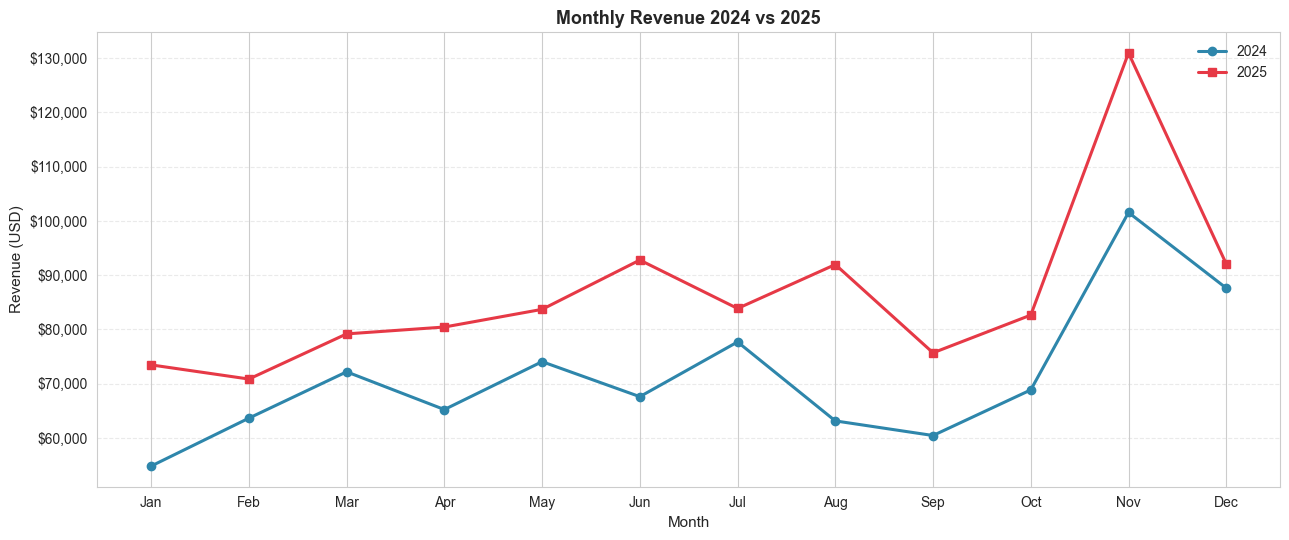

In [34]:
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.plot(pivot.index, pivot[2024], marker="o", linewidth=2.2, label="2024", color="#2E86AB")
ax.plot(pivot.index, pivot[2025], marker="s", linewidth=2.2, label="2025", color="#E63946")

ax.set_xlabel("Month")
ax.set_ylabel("Revenue (USD)")
ax.set_title("Monthly Revenue 2024 vs 2025")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.legend(frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{Charts}/01_monthly_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 2: Revenue by category

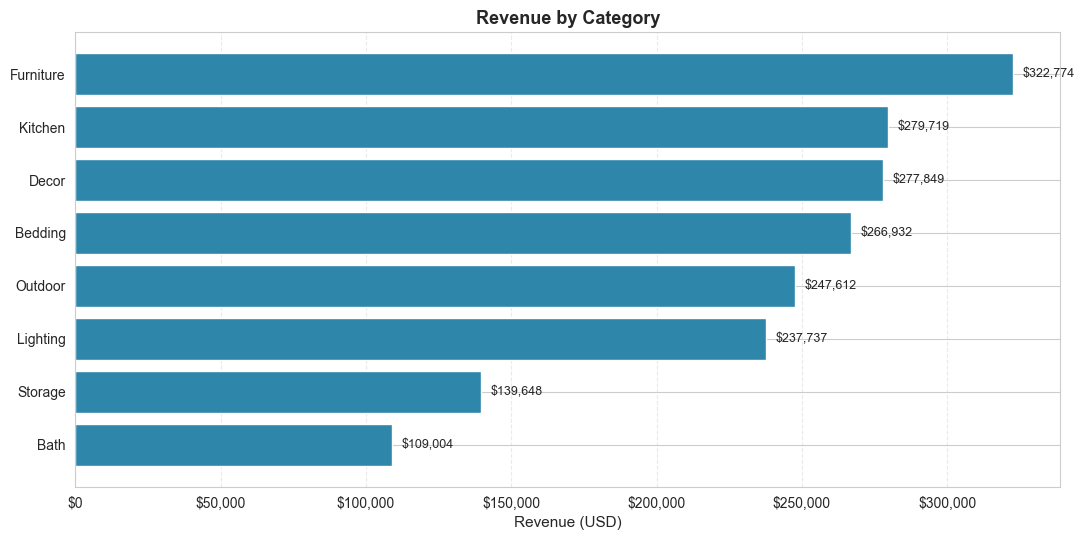

In [35]:
fig, ax = plt.subplots(figsize=(11, 5.5))

bars = ax.barh(cat_rev["category"], cat_rev["revenue"], color="#2E86AB", edgecolor="white")

ax.invert_yaxis()
ax.set_xlabel("Revenue (USD)")
ax.set_title("Revenue by Category")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.grid(axis="x", linestyle="--", alpha=0.4)

for bar, val in zip(bars, cat_rev["revenue"]):
    ax.text(
        bar.get_width() + cat_rev["revenue"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"${val:,.0f}",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(f"{Charts}/02_category_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 3: Return and cancel rates

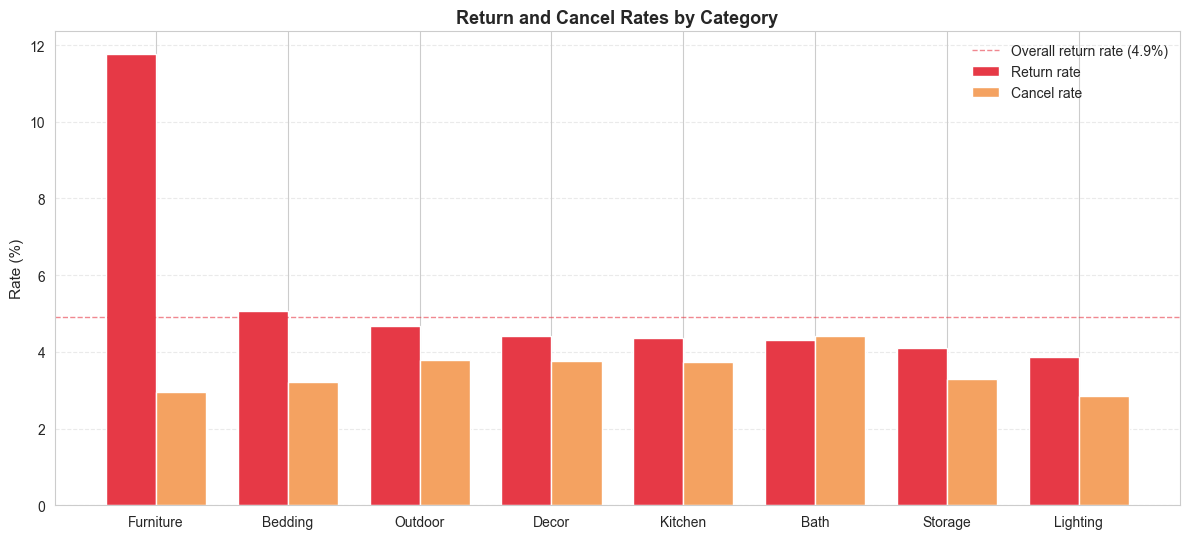

In [36]:
fig, ax = plt.subplots(figsize=(12, 5.5))

rates = status_by_cat[["return_rate", "cancel_rate"]].sort_values("return_rate", ascending=False)

x = np.arange(len(rates))
w = 0.38

ax.bar(x - w/2, rates["return_rate"], w, label="Return rate", color="#E63946", edgecolor="white")
ax.bar(x + w/2, rates["cancel_rate"], w, label="Cancel rate", color="#F4A261", edgecolor="white")

ax.axhline(
    overall_ret,
    color="#E63946",
    linestyle="--",
    linewidth=1,
    alpha=0.6,
    label=f"Overall return rate ({overall_ret:.1f}%)",
)

ax.set_xticks(x)
ax.set_xticklabels(rates.index)
ax.set_ylabel("Rate (%)")
ax.set_title("Return and Cancel Rates by Category")
ax.legend(frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{Charts}/03_return_cancel_rates.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 4: AOV by category

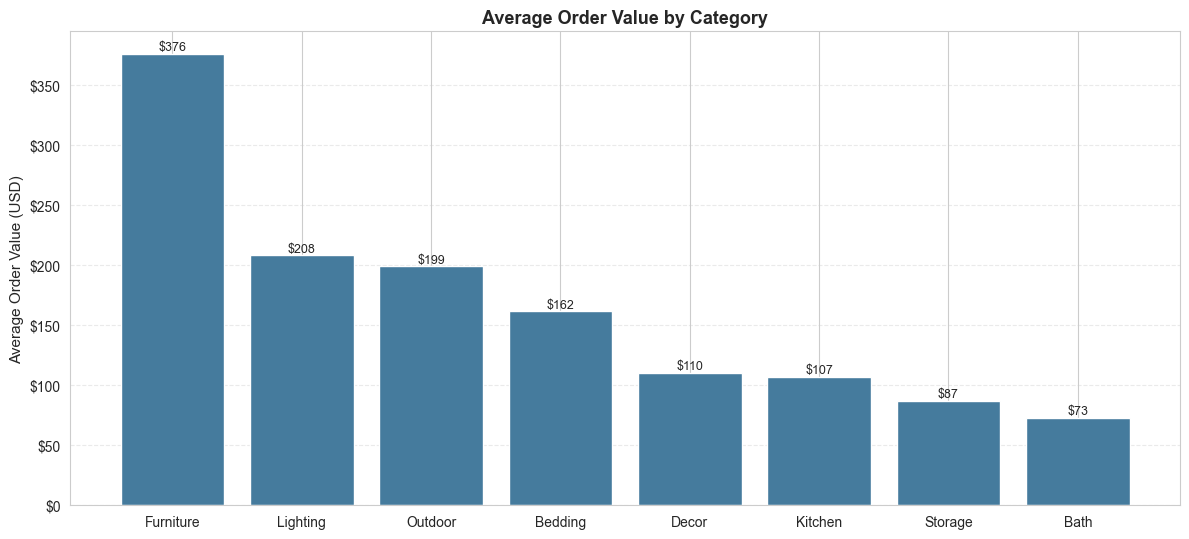

In [37]:
fig, ax = plt.subplots(figsize=(12, 5.5))

bars = ax.bar(aov.index, aov["avg_order_value"], color="#457B9D", edgecolor="white")

ax.set_ylabel("Average Order Value (USD)")
ax.set_title("Average Order Value by Category")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.grid(axis="y", linestyle="--", alpha=0.4)

for bar, val in zip(bars, aov["avg_order_value"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f"${val:,.0f}",
        ha="center",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(f"{Charts}/04_aov_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 5: Category mix

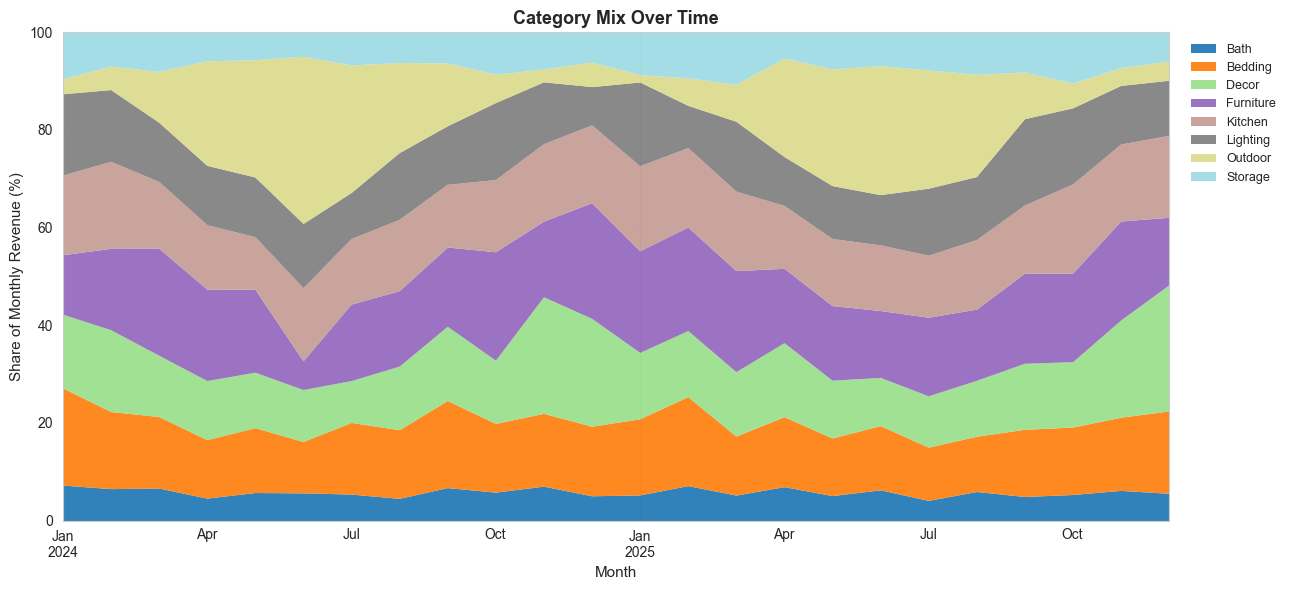

In [38]:
fig, ax = plt.subplots(figsize=(13, 6))

cat_month_pct.plot(
    kind="area",
    stacked=True,
    ax=ax,
    colormap="tab20",
    alpha=0.92,
    linewidth=0,
)

ax.set_ylabel("Share of Monthly Revenue (%)")
ax.set_xlabel("Month")
ax.set_title("Category Mix Over Time")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9, frameon=False)
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{Charts}/05_category_mix.png", dpi=150, bbox_inches="tight")
plt.show()

## Extra checks

A few things worth looking at beyond the brief. Profit margin, discount impact, and which acquisition channel drives the highest value orders. These are not required but they change the recommendations.

## Profit margin by category

In [39]:
completed_margin = completed.copy()
completed_margin["line_cost"] = completed_margin["quantity"] * completed_margin["unit_cost"]
completed_margin["line_profit"] = completed_margin["line_revenue"] - completed_margin["line_cost"]

margin_by_cat = (
    completed_margin
    .groupby("category")
    .agg(
        revenue=("line_revenue", "sum"),
        cost=("line_cost", "sum"),
        profit=("line_profit", "sum"),
    )
    .reset_index()
)

margin_by_cat["margin_pct"] = (margin_by_cat["profit"] / margin_by_cat["revenue"] * 100).round(2)
margin_by_cat = margin_by_cat.sort_values("margin_pct", ascending=False)

print("Profit margin by category:")
display(margin_by_cat.round(2))

Profit margin by category:


,category,revenue,cost,profit,margin_pct
7,Storage,"139,648.40","62,031.69","77,616.71",55.58
2,Decor,"277,848.70","135,615.07","142,233.63",51.19
1,Bedding,"266,931.61","130,362.12","136,569.49",51.16
6,Outdoor,"247,612.23","123,976.87","123,635.36",49.93
5,Lighting,"237,737.13","124,826.18","112,910.95",47.49
4,Kitchen,"279,719.21","147,408.87","132,310.34",47.30
0,Bath,"109,003.59","58,011.58","50,992.01",46.78
3,Furniture,"322,774.21","173,793.64","148,980.57",46.16


## Discount impact

In [40]:
disc = completed.copy()
disc["has_discount"] = disc["discount_amount"] > 0

disc_summary = (
    disc
    .groupby("has_discount")
    .agg(
        lines=("order_id", "count"),
        revenue=("line_revenue", "sum"),
        avg_line=("line_revenue", "mean"),
    )
    .round(2)
)

print("Discounted vs non discounted lines:")
display(disc_summary)

Discounted vs non discounted lines:


,lines,revenue,avg_line
has_discount,,,
False,12119,"1,649,638.74",136.12
True,2164,"231,636.34",107.04


## Acquisition channel value

In [41]:
channel_rev = (
    completed
    .groupby("order_id")
    .agg(total_revenue=("line_revenue", "sum"), channel=("acquisition_channel", "first"), customer=("customer_id", "first"))
    .reset_index()
)

channel_summary = (
    channel_rev
    .groupby("channel")
    .agg(
        orders=("order_id", "count"),
        customers=("customer", "nunique"),
        revenue=("total_revenue", "sum"),
        avg_order=("total_revenue", "mean"),
    )
    .round(2)
    .sort_values("revenue", ascending=False)
)

print("Revenue by acquisition channel:")
display(channel_summary)

Revenue by acquisition channel:


,orders,customers,revenue,avg_order
channel,,,,
organic_search,3458,741,"773,355.01",223.64
paid_search,1261,327,"290,267.46",230.19
referral,1247,248,"273,987.76",219.72
email,1132,271,"241,789.09",213.59
paid_social,1051,367,"238,330.70",226.77
affiliate,307,93,"63,545.06",206.99


## Top states by revenue

In [42]:
state_rev = (
    completed
    .groupby("state")
    .agg(revenue=("line_revenue", "sum"), orders=("order_id", "nunique"))
    .round(2)
    .sort_values("revenue", ascending=False)
    .head(10)
)

print("Top 10 states by revenue:")
display(state_rev)

Top 10 states by revenue:


,revenue,orders
state,,
CA,"256,447.46",1177
NY,"156,658.91",683
TX,"150,104.01",682
FL,"140,900.39",614
PA,"84,258.41",388
MI,"82,426.23",359
VA,"76,517.21",313
IL,"71,969.76",345
OH,"64,407.13",300


## Export analysis tables

In [43]:
monthly.to_csv(f"{Clean}/monthly_revenue.csv", index=False)
cat_rev.to_csv(f"{Clean}/category_performance.csv", index=False)
top_products.to_csv(f"{Clean}/top_products.csv", index=False)
status_by_cat.to_csv(f"{Clean}/category_status_rates.csv")
aov.to_csv(f"{Clean}/aov_by_category.csv")
margin_by_cat.to_csv(f"{Clean}/category_margins.csv", index=False)
channel_summary.to_csv(f"{Clean}/channel_summary.csv")

print(f"Analysis tables exported to {Clean}")

Analysis tables exported to C:/Users/vinay/OneDrive/Desktop/Data Science and Analytics Projects/Wayfair Sales Analysis/Data/Cleaned Data


## Summary Numbers

In [44]:
top_cat = cat_rev.iloc[0]
highest_return_cat = status_by_cat["return_rate"].idxmax()
highest_return_val = status_by_cat["return_rate"].max()
overall_aov = order_rev["total_revenue"].mean()
best_month_2025 = pivot[2025].idxmax()
worst_month_2025 = pivot[2025].replace(0, np.nan).idxmin()
top_channel = channel_summary.index[0]

print("=" * 60)
print("Summary Numbers")
print("=" * 60)
print(f"2024 revenue              : ${total_2024:,.2f}")
print(f"2025 revenue              : ${total_2025:,.2f}")
print(f"YoY growth                : {yoy:+.2f}%")
print(f"Completed orders          : {len(order_rev):,}")
print(f"Overall AOV               : ${overall_aov:,.2f}")
print(f"Top category              : {top_cat['category']} (${top_cat['revenue']:,.2f}, {top_cat['revenue_pct']:.1f}%)")
print(f"Highest AOV category      : {aov.index[0]} (${aov['avg_order_value'].iloc[0]:,.2f})")
print(f"Highest return category   : {highest_return_cat} ({highest_return_val:.2f}%)")
print(f"Best month 2025           : {best_month_2025} (${pivot[2025].max():,.2f})")
print(f"Worst month 2025          : {worst_month_2025} (${pivot[2025].replace(0, np.nan).min():,.2f})")
print(f"Top acquisition channel   : {top_channel}")
print("=" * 60)

Summary Numbers
2024 revenue              : $856,853.80
2025 revenue              : $1,037,556.78
YoY growth                : +21.09%
Completed orders          : 8,456
Overall AOV               : $224.03
Top category              : Furniture ($322,774.21, 17.2%)
Highest AOV category      : Furniture ($376.19)
Highest return category   : Furniture (11.77%)
Best month 2025           : Nov ($130,935.03)
Worst month 2025          : Feb ($70,854.29)
Top acquisition channel   : organic_search
